Imports and Setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BartTokenizer, BartForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Load and preprocess dataset

In [ ]:
df = pd.read_csv("CSSRS_suicide_train_cleaned.csv")

# Create gender_binary column if missing
if "gender_binary" not in df.columns and "gender" in df.columns:
    df["gender_binary"] = df["gender"].apply(lambda x: 1 if str(x).strip().lower() == "male" else 0)

# Create age_binary column if missing
if "age_binary" not in df.columns and "age_group" in df.columns:
    df["age_binary"] = df["age_group"].apply(lambda x: 1 if x in ["18-24", "25-34"] else 0)

# Filter valid classes and convert label to integer
df = df[df["label"].isin([0, 1, 2])].copy()
df["label"] = df["label"].astype(int)
df.head()

,text,original_label,label,gender,age_group,mental_health_history,therapy_use,medication_use,trauma_history,gender_binary,age_binary
0,please believe what this person said. i cant s...,ideation,0,female,13-17,undiagnosed,yes,no,unknown,0,0
1,right now? im scared. im worried my girlfriend...,behavior,1,male,50+,diagnosed,no,unknown,unknown,1,0
2,"youre not being a bitch, and you dont have to ...",supportive,2,unknown,35-49,undiagnosed,unknown,unknown,no,0,0
3,im feeling pretty emotionally low just now too...,supportive,2,unknown,50+,diagnosed,unknown,unknown,unknown,0,0
4,"what changed things for you?, thank you for be...",ideation,0,female,18-24,diagnosed,no,no,yes,0,1


Tokenization and custom dataset class

In [ ]:
tokenizer = BartTokenizer.from_pretrained("facebook/bart-base")

class CustomDataset(Dataset):
    def __init__(self, dataframe, tokenizer, sensitive_attr, max_len=128):
        self.encodings = tokenizer(
            dataframe["text"].tolist(),
            truncation=True,
            padding=True,
            max_length=max_len,
            return_tensors="pt"
        )
        self.labels = torch.tensor(dataframe["label"].values).long()
        self.sensitive = torch.tensor(dataframe[sensitive_attr].values).float().unsqueeze(1)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = self.labels[idx]
        item["sensitive_attr"] = self.sensitive[idx]
        return item

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

Gradient Reversal Layer for adversarial training

In [ ]:
class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input, lambda_):
        ctx.lambda_ = lambda_
        return input.view_as(input)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_ * grad_output, None

class GRL(nn.Module):
    def __init__(self, lambda_=1.0):
        super().__init__()
        self.lambda_ = lambda_

    def forward(self, input):
        return GradientReversalFunction.apply(input, self.lambda_)

Debiased BART model with adversary

In [ ]:
class DebiasedBART(nn.Module):
    def __init__(self, lambda_=0.1):
        super().__init__()
        self.bart = BartForSequenceClassification.from_pretrained("bart_cssrs_pretrained")
        self.grl = GRL(lambda_)
        self.adversary = nn.Sequential(
            nn.Linear(self.bart.config.hidden_size, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, input_ids, attention_mask):
        output = self.bart.model(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
        cls_embed = output.last_hidden_state[:, 0, :]
        logits = self.bart.classification_head(cls_embed)
        sensitive_pred = self.adversary(self.grl(cls_embed))
        return logits, sensitive_pred

Prepare data splits and loaders with sampling

In [ ]:
from torch.utils.data import WeightedRandomSampler

# Train/validation split
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

# Gender-based datasets and sampler to handle imbalance
gender_values = train_df["gender_binary"].values
class_counts = np.bincount(gender_values)
class_weights = 1. / class_counts
sample_weights = [class_weights[g] for g in gender_values]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_ds_gender = CustomDataset(train_df, tokenizer, "gender_binary")
val_ds_gender = CustomDataset(val_df, tokenizer, "gender_binary")
train_dl_gender = DataLoader(train_ds_gender, batch_size=8, sampler=sampler)
val_dl_gender = DataLoader(val_ds_gender, batch_size=8)

# Age-based datasets
train_ds_age = CustomDataset(train_df, tokenizer, "age_binary")
val_ds_age = CustomDataset(val_df, tokenizer, "age_binary")
train_dl_age = DataLoader(train_ds_age, batch_size=8, shuffle=True)
val_dl_age = DataLoader(val_ds_age, batch_size=8)

Pretrain BART (no debiasing)

In [ ]:
bart_model = BartForSequenceClassification.from_pretrained("facebook/bart-base", num_labels=3).to(device)
optimizer = optim.AdamW(bart_model.parameters(), lr=2e-5)
loss_fn = nn.CrossEntropyLoss()

# Train loop
for epoch in range(8):
    bart_model.train()
    total_loss = 0.0
    for batch in train_dl_gender:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = bart_model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"[Pretrain BART] Epoch {epoch+1}: Loss = {total_loss:.4f}")

# Save pretrained model and tokenizer
bart_model.save_pretrained("bart_cssrs_pretrained")
tokenizer.save_pretrained("bart_cssrs_pretrained")

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Some weights of BartForSequenceClassification were not initialized from the model checkpoint at facebook/bart-base and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[Pretrain BART] Epoch 1: Loss = 30.3213
[Pretrain BART] Epoch 2: Loss = 27.0740
[Pretrain BART] Epoch 3: Loss = 20.3199
[Pretrain BART] Epoch 4: Loss = 16.3228
[Pretrain BART] Epoch 5: Loss = 13.2937
[Pretrain BART] Epoch 6: Loss = 10.1790
[Pretrain BART] Epoch 7: Loss = 5.5459
[Pretrain BART] Epoch 8: Loss = 4.3533


/usr/local/lib/python3.11/dist-packages/transformers/configuration_utils.py:393: UserWarning: Some non-default generation parameters are set in the model config. These should go into either a) `model.generation_config` (as opposed to `model.config`); OR b) a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model).This warning will become an exception in the future.
Non-default generation parameters: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}
  warnings.warn(


('bart_cssrs_pretrained/tokenizer_config.json',
 'bart_cssrs_pretrained/special_tokens_map.json',
 'bart_cssrs_pretrained/vocab.json',
 'bart_cssrs_pretrained/merges.txt',
 'bart_cssrs_pretrained/added_tokens.json')

Adversarial Training Loop

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Compute balanced class weights
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_df["label"]), y=train_df["label"])
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# Initialize model, optimizer, and losses
model = DebiasedBART(lambda_=0.1).to(device)
optimizer = optim.AdamW(model.parameters(), lr=2e-5)
loss_main = nn.CrossEntropyLoss(weight=class_weights_tensor)
loss_adv = nn.BCELoss()

# Training loop with adversarial loss
for epoch in range(8):
    model.train()
    total_main, total_adv = 0, 0

    for batch in train_dl_gender:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        sensitive = batch["sensitive_attr"].to(device).float()

        optimizer.zero_grad()
        logits, sensitive_pred = model(input_ids, attention_mask)

        loss1 = loss_main(logits, labels)
        loss2 = loss_adv(sensitive_pred, sensitive)

        (loss1 + loss2).backward()
        optimizer.step()

        total_main += loss1.item()
        total_adv += loss2.item()

    print(f"[Gender] Epoch {epoch+1}: Main Loss = {total_main:.4f}, Adv Loss = {total_adv:.4f}")

[Gender] Epoch 1: Main Loss = 30.6550, Adv Loss = 20.4174
[Gender] Epoch 2: Main Loss = 24.6976, Adv Loss = 20.9346
[Gender] Epoch 3: Main Loss = 18.6519, Adv Loss = 20.9308
[Gender] Epoch 4: Main Loss = 20.1165, Adv Loss = 21.0445
[Gender] Epoch 5: Main Loss = 15.9621, Adv Loss = 20.8749
[Gender] Epoch 6: Main Loss = 13.1912, Adv Loss = 20.7899
[Gender] Epoch 7: Main Loss = 8.3598, Adv Loss = 20.8367
[Gender] Epoch 8: Main Loss = 6.0812, Adv Loss = 21.5989


Fairness Evaluation and Visualization

In [ ]:
!pip install fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 6.2 MB/s eta 0:00:00



Classification Report (Gender Binary):
              precision    recall  f1-score   support

           0       0.68      0.70      0.69        28
           1       0.57      0.50      0.53        13
           2       0.67      0.76      0.71        18

    accuracy                           0.67        59
   macro avg       0.64      0.65      0.64        59
weighted avg       0.66      0.67      0.66        59


Group-wise Accuracy (Gender):
Group 0 (Gender): Accuracy = 0.7023
Group 1 (Gender): Accuracy = 0.7358

Classification Report (Age Binary):
              precision    recall  f1-score   support

           0       0.68      0.74      0.71        30
           1       0.63      0.60      0.61        29
           2       0.70      0.78      0.74        25

    accuracy                           0.68        84
   macro avg       0.67      0.71      0.69        84
weighted avg       0.68      0.68      0.68        84


Group-wise Accuracy (Age):
Group 0 (Age): Accuracy = 0.72

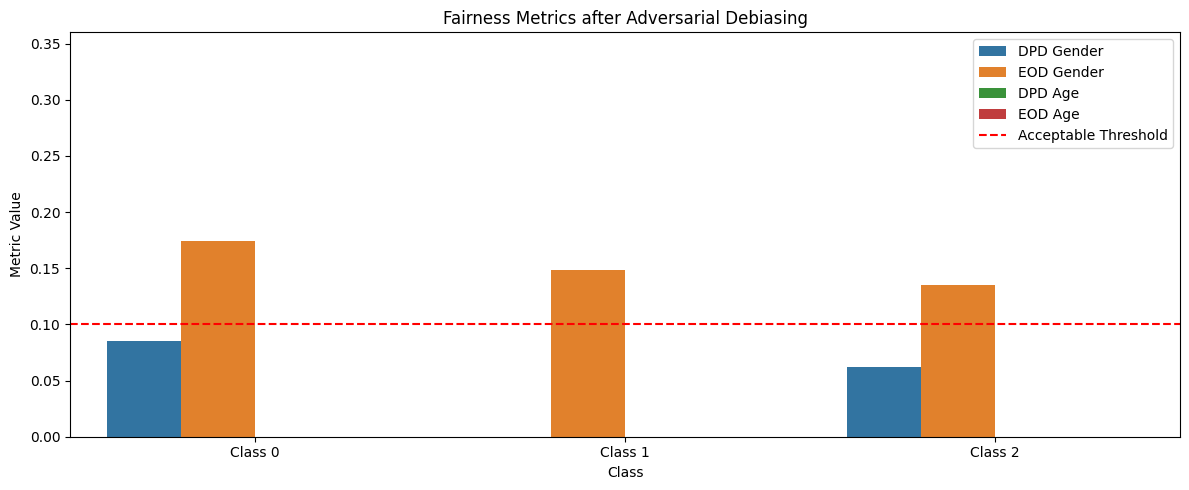

In [ ]:
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference, MetricFrame
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Put model in eval mode
torch.manual_seed(42)
model.eval()

# === Generate predictions on validation set (Gender-based) ===
all_preds_gender, all_labels_gender, all_gender = [], [], []
with torch.no_grad():
    for batch in val_dl_gender:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].cpu().numpy()
        gender = batch["sensitive_attr"].cpu().numpy().flatten()

        logits, _ = model(input_ids, attention_mask)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds_gender.extend(preds)
        all_labels_gender.extend(labels)
        all_gender.extend(gender)

# === Generate predictions on validation set (Age-based) ===
all_preds_age, all_labels_age, all_age = [], [], []
with torch.no_grad():
    for batch in val_dl_age:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].cpu().numpy()
        age = batch["sensitive_attr"].cpu().numpy().flatten()

        logits, _ = model(input_ids, attention_mask)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds_age.extend(preds)
        all_labels_age.extend(labels)
        all_age.extend(age)

# === Combine into DataFrames ===
val_df_gender = pd.DataFrame({
    "label": all_labels_gender,
    "prediction": all_preds_gender,
    "gender_binary": all_gender
})

val_df_age = pd.DataFrame({
    "label": all_labels_age,
    "prediction": all_preds_age,
    "age_binary": all_age
})

# === Classification Report & Group Accuracy ===
print("\nClassification Report (Gender Binary):")
print(classification_report(val_df_gender["label"], val_df_gender["prediction"], zero_division=0))

print("\nGroup-wise Accuracy (Gender):")
for name, group in val_df_gender.groupby("gender_binary"):
    acc = np.mean(group["prediction"] == group["label"])
    print(f"Group {int(name)} (Gender): Accuracy = {acc:.4f}")

print("\nClassification Report (Age Binary):")
print(classification_report(val_df_age["label"], val_df_age["prediction"], zero_division=0))

print("\nGroup-wise Accuracy (Age):")
for name, group in val_df_age.groupby("age_binary"):
    acc = np.mean(group["prediction"] == group["label"])
    print(f"Group {int(name)} (Age): Accuracy = {acc:.4f}")

# === Compute DPD & EOD per Class for both attributes ===
y_true_gender = val_df_gender["label"].to_numpy()
y_pred_gender = val_df_gender["prediction"].to_numpy()
gender_attr = val_df_gender["gender_binary"].to_numpy()

y_true_age = val_df_age["label"].to_numpy()
y_pred_age = val_df_age["prediction"].to_numpy()
age_attr = val_df_age["age_binary"].to_numpy()

class_names = ['Class 0', 'Class 1', 'Class 2']
metrics_data = []

for class_label, class_name in enumerate(class_names):
    # Gender
    y_true_bin_gender = (y_true_gender == class_label).astype(int)
    y_pred_bin_gender = (y_pred_gender == class_label).astype(int)

    dpd_gender = demographic_parity_difference(y_true_bin_gender, y_pred_bin_gender, sensitive_features=gender_attr)
    eod_gender = equalized_odds_difference(y_true_bin_gender, y_pred_bin_gender, sensitive_features=gender_attr)

    # Age
    y_true_bin_age = (y_true_age == class_label).astype(int)
    y_pred_bin_age = (y_pred_age == class_label).astype(int)

    dpd_age = demographic_parity_difference(y_true_bin_age, y_pred_bin_age, sensitive_features=age_attr)
    eod_age = equalized_odds_difference(y_true_bin_age, y_pred_bin_age, sensitive_features=age_attr)

    metrics_data.extend([
        {"Class": class_name, "Metric": "DPD Gender", "Value": dpd_gender},
        {"Class": class_name, "Metric": "EOD Gender", "Value": eod_gender},
        {"Class": class_name, "Metric": "DPD Age", "Value": dpd_age},
        {"Class": class_name, "Metric": "EOD Age", "Value": eod_age},
    ])

# === Final Plot ===
metrics_df = pd.DataFrame(metrics_data)
plt.figure(figsize=(12, 5))
sns.barplot(data=metrics_df, x='Class', y='Value', hue='Metric')
plt.title("Fairness Metrics after Adversarial Debiasing")
plt.axhline(0.1, color='red', linestyle='--', label='Acceptable Threshold')
plt.ylim(0, 0.36)
plt.ylabel("Metric Value")
plt.tight_layout()
plt.legend()
plt.show()